# ProstT5 Inverse Folding — Baseline Performance (3Di → AA)

This notebook establishes the **baseline performance** for inverse-folding (3Di → AA) for two pipelines:

1. **enc–dec**: the full `Rostlab/ProstT5_fp16` encoder–decoder, autoregressive generation with greedy decoding.
2. **enc–CNN**: the ProstT5 **encoder only** + a tiny **CNN head** (`cnn_chkpnt_AA_CNN/model.pt`) that emits per-residue AA logits in **one parallel pass**.

For a **100-protein test set** stratified by length, structure, organism, and MSA depth, we measure:

- **Latency** (s/protein, end-to-end median over repeats)
- **Throughput** (tokens/s = generated AA tokens / wall time)
- **Peak vRAM** (GB)
- **Greedy agreement** (per-residue AA identity, confusion matrix, positional analysis)
- **Sampling-based acceptance rate α** (Leviathan's speculative-sampling rule)

Pipeline outline:

1. Mount Google Drive for model caching + checkpointing
2. Load ProstT5 encoder–decoder + CNN head
3. Build 100-protein test set from AlphaFoldDB + Foldseek
4. Benchmark latency/throughput/vRAM for both pipelines
5. Extended agreement evaluation + α measurement across sampling configs

In [1]:
%pip install tiktoken sentencepiece torch
%pip install 'accelerate>=0.26.0'
%pip install "transformers==4.46.3" "protobuf>=3.20" sentencepiece

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 75.7 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 84.9 MB/s eta 0:00:00:00:01
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
N

In [ ]:
#@title Google Drive mount + HF cache redirect. { display-mode: "form" }
import os

# Prevent transformers from loading TensorFlow (avoids protobuf version conflict on Colab)
os.environ["USE_TF"] = "0"

try:
    from google.colab import drive
    drive.mount('/content/drive')
    os.environ["HF_HOME"] = "/content/drive/MyDrive/hf_cache"
    DRIVE_ROOT = "/content/drive/MyDrive/prostT5_benchmarks"
    os.makedirs(DRIVE_ROOT, exist_ok=True)
    print(f"Google Drive mounted. HF cache -> {os.environ['HF_HOME']}")
    print(f"Checkpoint dir -> {DRIVE_ROOT}")
    USE_DRIVE = True
except (ImportError, ModuleNotFoundError):
    print("Not on Colab or Drive unavailable; using local paths.")
    DRIVE_ROOT = None
    USE_DRIVE = False

Kaggle Drive mounted. HF cache -> /kaggle/working/hf_cache
Checkpoint dir -> /kaggle/working/prostT5_benchmarks


In [13]:
#@title Imports + device check. { display-mode: "form" }
import os, time, json, gc, statistics, subprocess, shutil, pickle
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
from transformers import T5Tokenizer, AutoModelForSeq2SeqLM

shutil.rmtree("/kaggle/working/prostT5_benchmarks")
shutil.copytree("/kaggle/input/datasets/vietp253/prostt5-benchmarks", "/kaggle/working/prostT5_benchmarks")


if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"torch={torch.__version__}  device={device}")
if device.type == "cpu":
    print("WARNING: running on CPU — timings will not reflect realistic GPU latency.")

torch=2.10.0+cu128  device=cuda:0


In [14]:
#@title Configuration. { display-mode: "form" }
PROSTT5_NAME = "Rostlab/ProstT5_fp16"
NOTEBOOK_DIR = Path(".").resolve()

# Locate project files (prefer Drive path on Colab, fallback to local)
if USE_DRIVE:
    PROJECT_DIR = Path(DRIVE_ROOT)
else:
    PROJECT_DIR = NOTEBOOK_DIR

CNN_CKPT = PROJECT_DIR / "model.pt"
if not CNN_CKPT.exists():
    # Fallback: try local paths
    for candidate in [NOTEBOOK_DIR / "model.pt",
                      NOTEBOOK_DIR / "cnn_chkpnt_AA_CNN" / "model.pt"]:
        if candidate.exists():
            CNN_CKPT = candidate
            break

DATA_DIR = NOTEBOOK_DIR / "benchmark_data"
RESULTS_DIR = NOTEBOOK_DIR / "benchmark_results"
DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Checkpoint dir (persistent across Colab restarts if Drive is mounted)
if USE_DRIVE:
    CHECKPOINT_DIR = Path(DRIVE_ROOT) / "checkpoints"
else:
    CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Benchmark protocol
NUM_WARMUP = 2          # untimed model.generate calls before the timed ones
NUM_REPEATS = 3         # timed repeats per protein (we report median)
USE_FP16 = True         # ProstT5 ships an fp16 checkpoint

# AA vocabulary order used by the ProstT5 AA-CNN head (20 std amino acids, alphabetical).
AA_LETTERS = "ACDEFGHIKLMNPQRSTVWY"
assert len(AA_LETTERS) == 20

# Sampling configurations for alpha measurement
SAMPLING_CONFIGS = {
    "greedy_T1.0": {"temperature": 1.0, "top_k": 0, "top_p": 1.0},
    "published_T1.0_k3_p0.85": {"temperature": 1.0, "top_k": 3, "top_p": 0.85},
    "conservative_T0.5": {"temperature": 0.5, "top_k": 0, "top_p": 1.0},
    "exploratory_T1.5": {"temperature": 1.5, "top_k": 0, "top_p": 1.0},
}

print(f"CNN checkpoint: {CNN_CKPT}  (exists: {CNN_CKPT.exists()})")
print(f"Project dir: {PROJECT_DIR}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"Sampling configs: {list(SAMPLING_CONFIGS.keys())}")

CNN checkpoint: /kaggle/working/prostT5_benchmarks/model.pt  (exists: True)
Project dir: /kaggle/working/prostT5_benchmarks
Checkpoint dir: /kaggle/working/prostT5_benchmarks/checkpoints
Sampling configs: ['greedy_T1.0', 'published_T1.0_k3_p0.85', 'conservative_T0.5', 'exploratory_T1.5']


In [15]:
#@title Load ProstT5 (tokenizer + full encoder–decoder). { display-mode: "form" }
tokenizer = T5Tokenizer.from_pretrained(PROSTT5_NAME, do_lower_case=False, legacy=True)

dtype = torch.float16 if (USE_FP16 and device.type == "cuda") else torch.float32
model = AutoModelForSeq2SeqLM.from_pretrained(
    PROSTT5_NAME,
    low_cpu_mem_usage=True,
    torch_dtype=dtype,
).to(device).eval()
if dtype == torch.float16:
    model = model.half()

# We will reuse the same encoder for the enc-CNN path (no second copy of the weights).
encoder = model.get_encoder()

print(f"ProstT5 loaded. dtype={next(model.parameters()).dtype}  "
      f"params(M)={sum(p.numel() for p in model.parameters())/1e6:.1f}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/733 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.64G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.64G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

ProstT5 loaded. dtype=torch.float16  params(M)=2818.9


In [16]:
#@title Define + load the AA CNN head. { display-mode: "form" }
class AACNN(nn.Module):
    def __init__(self, num_tokens: int = 20, hidden: int = 32, in_dim: int = 1024):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Conv2d(in_dim, hidden, kernel_size=(7, 1), padding=(3, 0)),
            nn.ReLU(),
            nn.Dropout(0.0),
            nn.Conv2d(hidden, num_tokens, kernel_size=(7, 1), padding=(3, 0)),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.permute(0, 2, 1).unsqueeze(-1)
        x = self.classifier(x)
        return x.squeeze(-1).permute(0, 2, 1)


cnn = AACNN(num_tokens=20).to(device).eval()
ckpt = torch.load(CNN_CKPT, map_location=device, weights_only=False)
state_dict = ckpt.get("state_dict", ckpt)
missing, unexpected = cnn.load_state_dict(state_dict, strict=True)
print(f"CNN loaded. missing={missing} unexpected={unexpected}")
print(f"CNN params: {sum(p.numel() for p in cnn.parameters()):,}")

CNN loaded. missing=[] unexpected=[]
CNN params: 233,908


In [17]:
#@title 100-protein test set definition. { display-mode: "form" }
import sys
sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(NOTEBOOK_DIR))

try:
    from test_set_100 import TEST_SET, TEST_IDS, BACKUP_IDS
    print(f"Loaded {len(TEST_SET)} proteins from test_set_100.py")
except ImportError:
    print("test_set_100.py not found; using fallback inline list.")
    TEST_IDS = [
        "P62990", "P01308", "P02798", "P62944", "P01542",
        "P43408", "P0AFL6", "P0ACJ8", "P0A988", "P0A7Y4",
        "Q57733", "P22579", "P15378", "P34690", "P0A7U3",
        "P63165", "P0A7N4", "P24311", "P56252", "P18253",
        "A0A6G0XC32", "P42212", "P61626", "P68871", "P37840",
        "P02686", "P61769", "P00720", "P0ABH7", "P0A9Q7",
        "P0A953", "P00698", "P0DP27", "P62937", "P10599",
        "P56201", "P16949", "P68082", "P63101", "Q9R0Q7",
        "P04637", "P0DTC9", "P0AEX9", "P00918", "P0A855",
        "P00784", "P69441", "P02572", "P63244", "P00439",
        "P62593", "P00766", "P0A6P9", "P04406", "P24941",
        "P02994", "P61583", "P05089", "P07688", "P06280",
        "P19367", "P0A6F5", "P02768", "P08684", "P35354",
        "P04150", "P0AG67", "P15056", "P05067", "P0ABB0",
        "P23246", "P21802", "P11413", "P07901", "Q02880",
        "P14598", "P10591", "P61869", "P10275", "P00832",
        "P38398", "P02452", "P12821", "P00968", "P42336",
        "P42345", "P0DTC2", "P13569", "O60885", "P06756",
        "P04626", "Q13936", "P02458", "Q61410", "P13368",
        "P04808", "Q04721", "P07949", "P35498", "P00533",
    ]
    BACKUP_IDS = [
        "P0A7L0", "P01375", "P62988", "P00441", "P00517",
        "P04040", "P22303", "P11362", "Q9NZC2", "P54289",
    ]

print(f"#proteins in main set: {len(TEST_IDS)}")
print(f"#backup proteins: {len(BACKUP_IDS)}")

Loaded 100 proteins from test_set_100.py
#proteins in main set: 100
#backup proteins: 10


In [18]:
#@title Build the test-set 3Di FASTA (download AFDB + run Foldseek). { display-mode: "form" }
import platform, urllib.request, tarfile, stat

TEST_FASTA = DATA_DIR / "test_set_3Di.fasta"
TEST_AA_FASTA = DATA_DIR / "test_set_AA.fasta"
FOLDSEEK_DIR = NOTEBOOK_DIR / "foldseek_bin"


def _foldseek_url() -> str | None:
    sysname = platform.system()
    if sysname == "Linux":
        return "https://mmseqs.com/foldseek/foldseek-linux-avx2.tar.gz"
    if sysname == "Darwin":
        return "https://mmseqs.com/foldseek/foldseek-osx-universal.tar.gz"
    return None


def _have_foldseek() -> str | None:
    on_path = shutil.which("foldseek")
    if on_path:
        return on_path
    candidates = [
        FOLDSEEK_DIR / "bin" / "foldseek",
        NOTEBOOK_DIR / "foldseek" / "bin" / "foldseek",
        Path("/content/foldseek/bin/foldseek"),
        Path.cwd() / "foldseek" / "bin" / "foldseek",
        Path("/tmp/foldseek/bin/foldseek"),
        Path("/usr/local/bin/foldseek"),
    ]
    for c in candidates:
        if c.exists() and os.access(c, os.X_OK):
            return str(c)
    for root in {NOTEBOOK_DIR, Path.cwd(), Path("/content"), Path("/tmp")}:
        if not root.exists():
            continue
        for hit in root.glob("**/foldseek/bin/foldseek"):
            if hit.is_file() and os.access(hit, os.X_OK):
                return str(hit)
    return None


def _install_foldseek() -> str:
    FOLDSEEK_DIR.mkdir(parents=True, exist_ok=True)
    url = _foldseek_url()
    if url is None:
        raise RuntimeError(
            f"Auto-install not supported on {platform.system()}/{platform.machine()}. "
            "Install foldseek manually and put it on PATH, "
            f"or drop pre-built FASTAs at {TEST_FASTA} / {TEST_AA_FASTA}."
        )
    tarball = FOLDSEEK_DIR / "foldseek.tar.gz"
    if not tarball.exists():
        print(f"Downloading foldseek from {url} ...")
        urllib.request.urlretrieve(url, tarball)
    print(f"Extracting {tarball} ...")
    with tarfile.open(tarball, "r:gz") as tf:
        tf.extractall(FOLDSEEK_DIR)
    src_bin = FOLDSEEK_DIR / "foldseek" / "bin" / "foldseek"
    dst_bin = FOLDSEEK_DIR / "bin" / "foldseek"
    if src_bin.exists():
        dst_bin.parent.mkdir(parents=True, exist_ok=True)
        if dst_bin.exists():
            dst_bin.unlink()
        shutil.copy(src_bin, dst_bin)
        st = dst_bin.stat()
        dst_bin.chmod(st.st_mode | stat.S_IXUSR | stat.S_IXGRP | stat.S_IXOTH)
        return str(dst_bin)
    raise RuntimeError(f"foldseek binary not found after extracting {tarball}")


def _ensure_foldseek() -> str:
    fs = _have_foldseek()
    if fs is not None:
        return fs
    print("foldseek not found in any known location; auto-installing ...")
    fs = _install_foldseek()
    print(f"foldseek installed at: {fs}")
    return fs


def _afdb_pdb_url(uniprot_id: str) -> str:
    api = f"https://alphafold.ebi.ac.uk/api/prediction/{uniprot_id}"
    with urllib.request.urlopen(api, timeout=15) as r:
        body = json.loads(r.read())
    if not body or not isinstance(body, list):
        raise RuntimeError(f"AFDB API returned no entries for {uniprot_id}")
    pdb_url = body[0].get("pdbUrl")
    if not pdb_url:
        raise RuntimeError(f"AFDB API entry for {uniprot_id} has no pdbUrl")
    return pdb_url


def _download_pdb(uniprot_id: str, out_dir: Path) -> Path:
    out_dir.mkdir(parents=True, exist_ok=True)
    pdb = out_dir / f"AF-{uniprot_id}-F1-model.pdb"
    if pdb.exists() and pdb.stat().st_size > 0:
        return pdb
    url = _afdb_pdb_url(uniprot_id)
    urllib.request.urlretrieve(url, pdb)
    return pdb


def _extract_3di(uniprot_id: str, pdb: Path, foldseek: str) -> tuple[str, str]:
    work = DATA_DIR / "foldseek_work" / uniprot_id
    work.mkdir(parents=True, exist_ok=True)
    pdb_dir = work / "pdbs"
    pdb_dir.mkdir(exist_ok=True)
    target = pdb_dir / pdb.name
    if not target.exists():
        shutil.copy(pdb, target)
    db = work / "queryDB"
    subprocess.run([foldseek, "createdb", str(pdb_dir), str(db)], check=True,
                   capture_output=True)
    subprocess.run([foldseek, "lndb", str(db) + "_h", str(db) + "_ss_h"], check=True,
                   capture_output=True)
    aa_fasta = work / "queryDB.fasta"
    di_fasta = work / "queryDB_ss.fasta"
    subprocess.run([foldseek, "convert2fasta", str(db), str(aa_fasta)], check=True,
                   capture_output=True)
    subprocess.run([foldseek, "convert2fasta", str(db) + "_ss", str(di_fasta)], check=True,
                   capture_output=True)

    def read_one(p: Path, lower: bool) -> str:
        seq = []
        for line in p.read_text().splitlines():
            if line.startswith(">"): continue
            seq.append(line.strip())
        s = "".join(seq).replace("-", "")
        return s.lower() if lower else s

    return read_one(aa_fasta, lower=False), read_one(di_fasta, lower=True)


def build_test_set(ids: list[str]) -> dict[str, dict]:
    if TEST_FASTA.exists() and TEST_AA_FASTA.exists():
        print(f"Reusing cached FASTA: {TEST_FASTA}")
        out: dict[str, dict] = {}
        cur = None
        for line in TEST_AA_FASTA.read_text().splitlines():
            if line.startswith(">"):
                cur = line[1:].split()[0]
                out.setdefault(cur, {})["aa"] = ""
            elif cur:
                out[cur]["aa"] += line.strip()
        cur = None
        for line in TEST_FASTA.read_text().splitlines():
            if line.startswith(">"):
                cur = line[1:].split()[0]
                out.setdefault(cur, {})["3di"] = ""
            elif cur:
                out[cur]["3di"] += line.strip().lower()
        for uid, rec in out.items():
            rec["length"] = len(rec.get("3di", ""))
        return out

    foldseek = _ensure_foldseek()
    out: dict[str, dict] = {}
    pdb_root = DATA_DIR / "afdb_pdbs"
    failed = []
    for i, uid in enumerate(ids):
        try:
            pdb = _download_pdb(uid, pdb_root)
            aa, di = _extract_3di(uid, pdb, foldseek)
            if not aa or not di or len(aa) != len(di):
                print(f"  SKIP {uid}: bad AA/3Di (lengths {len(aa)} vs {len(di)})")
                failed.append(uid)
                continue
            out[uid] = {"aa": aa, "3di": di, "length": len(di)}
            if (i + 1) % 10 == 0 or i == 0:
                print(f"  [{i+1}/{len(ids)}] OK {uid}  L={len(di):4d}")
        except Exception as e:
            print(f"  FAIL {uid}: {e}")
            failed.append(uid)

    with TEST_AA_FASTA.open("w") as f:
        for uid, rec in out.items():
            f.write(f">{uid}\n{rec['aa']}\n")
    with TEST_FASTA.open("w") as f:
        for uid, rec in out.items():
            f.write(f">{uid}\n{rec['3di']}\n")

    if failed:
        print(f"\nFailed proteins ({len(failed)}): {failed}")
        print("Attempting backup replacements...")
        for backup_uid in BACKUP_IDS:
            if not failed:
                break
            try:
                pdb = _download_pdb(backup_uid, pdb_root)
                aa, di = _extract_3di(backup_uid, pdb, foldseek)
                if aa and di and len(aa) == len(di):
                    out[backup_uid] = {"aa": aa, "3di": di, "length": len(di)}
                    failed.pop(0)
                    print(f"  BACKUP OK {backup_uid}  L={len(di):4d}")
            except Exception as e:
                print(f"  BACKUP FAIL {backup_uid}: {e}")
    return out


test_set = build_test_set(TEST_IDS)
print(f"\nFinal test set: {len(test_set)} proteins")
lengths = sorted(rec["length"] for rec in test_set.values())
print(f"Length range: {lengths[0]}-{lengths[-1]} residues")

foldseek not found in any known location; auto-installing ...
Extracting /kaggle/working/foldseek_bin/foldseek.tar.gz ...


/tmp/ipykernel_57/3578150681.py:57: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(FOLDSEEK_DIR)


foldseek installed at: /kaggle/working/foldseek_bin/bin/foldseek
  FAIL P62990: HTTP Error 404: Not Found
  [10/100] OK P0A7Y4  L= 155
  [20/100] OK P18253  L= 162
  FAIL P00720: HTTP Error 404: Not Found
  [30/100] OK P0A9Q7  L= 891
  [40/100] OK Q9R0Q7  L= 160
  [50/100] OK P00439  L= 452
  [60/100] OK P06280  L= 429
  [70/100] OK P0ABB0  L= 513
  FAIL P00832: HTTP Error 404: Not Found
  [90/100] OK P06756  L=1048
  [100/100] OK P00533  L=1210

Failed proteins (3): ['P62990', 'P00720', 'P00832']
Attempting backup replacements...
  BACKUP OK P0A7L0  L= 234
  BACKUP OK P01375  L= 233
  BACKUP FAIL P62988: HTTP Error 404: Not Found
  BACKUP OK P00441  L= 154

Final test set: 100 proteins
Length range: 46-2554 residues


## Step 2 — Helpers

In [20]:
#@title Helper: timing utilities. { display-mode: "form" }
def _sync():
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def _reset_peak_mem():
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)


def _peak_mem_gb() -> float:
    if device.type == "cuda":
        return torch.cuda.max_memory_allocated(device) / 1e9
    return 0.0


def _format_3di(seq: str) -> str:
    return "<fold2AA> " + " ".join(list(seq.lower()))


def _decode_aa(token_ids: torch.Tensor) -> str:
    s = tokenizer.decode(token_ids, skip_special_tokens=True)
    return "".join(s.split())

In [21]:
#@title Helper: enc–dec inverse-folding (greedy, autoregressive). { display-mode: "form" }
@torch.inference_mode()
def time_encdec(uid: str, three_di: str,
                num_warmup: int = NUM_WARMUP,
                num_repeats: int = NUM_REPEATS) -> tuple[list[dict], str]:
    L = len(three_di)
    enc = tokenizer(
        [_format_3di(three_di)],
        add_special_tokens=True,
        return_tensors="pt",
    ).to(device)

    gen_kwargs = dict(
        input_ids=enc.input_ids,
        attention_mask=enc.attention_mask,
        max_length=L + 2,
        min_length=L + 1,
        num_beams=1,
        do_sample=False,
        num_return_sequences=1,
    )

    for _ in range(num_warmup):
        _ = model.generate(**gen_kwargs)
    _sync()

    rows = []
    last_pred = ""
    for r in range(num_repeats):
        _reset_peak_mem()
        _sync()
        t0 = time.perf_counter()
        out = model.generate(**gen_kwargs)
        _sync()
        dt = time.perf_counter() - t0

        n_new = int(out.shape[1] - 1)
        pred_aa = _decode_aa(out[0])[:L]  # truncate to expected length
        last_pred = pred_aa
        rows.append({
            "protein_id": uid,
            "pipeline": "enc_dec",
            "length": L,
            "repeat": r,
            "wall_s": dt,
            "tokens_per_s": n_new / dt if dt > 0 else float("nan"),
            "peak_vram_gb": _peak_mem_gb(),
            "pred_len": len(pred_aa),
        })
    return rows, last_pred

In [22]:
#@title Helper: enc–CNN inverse-folding (encoder + CNN, one parallel pass). { display-mode: "form" }
@torch.inference_mode()
def time_enccnn(uid: str, three_di: str,
                num_warmup: int = NUM_WARMUP,
                num_repeats: int = NUM_REPEATS) -> tuple[list[dict], str]:
    L = len(three_di)
    enc = tokenizer(
        [_format_3di(three_di)],
        add_special_tokens=True,
        return_tensors="pt",
    ).to(device)

    def _forward() -> torch.Tensor:
        h = encoder(
            input_ids=enc.input_ids,
            attention_mask=enc.attention_mask,
        ).last_hidden_state
        h = h[:, 1:-1, :]
        logits = cnn(h.float())
        return logits

    for _ in range(num_warmup):
        _ = _forward()
    _sync()

    rows = []
    last_pred = ""
    for r in range(num_repeats):
        _reset_peak_mem()
        _sync()
        t0 = time.perf_counter()
        logits = _forward()
        ids = logits.argmax(-1)
        _sync()
        dt = time.perf_counter() - t0

        pred_aa = "".join(AA_LETTERS[int(i)] for i in ids[0].tolist())
        last_pred = pred_aa
        rows.append({
            "protein_id": uid,
            "pipeline": "enc_cnn",
            "length": L,
            "repeat": r,
            "wall_s": dt,
            "tokens_per_s": len(pred_aa) / dt if dt > 0 else float("nan"),
            "peak_vram_gb": _peak_mem_gb(),
            "pred_len": len(pred_aa),
        })
    return rows, last_pred

In [23]:
#@title Helper: acceptance rate α computation. { display-mode: "form" }

# ProstT5 generates space-separated AAs, so tokens are ▁A, ▁C, ... (not bare A, C, ...).
# convert_tokens_to_ids("A") returns <unk> (ID=2) — must use encode(" A") instead.
AA_TOKEN_IDS = [tokenizer.encode(f" {aa}", add_special_tokens=False)[0] for aa in AA_LETTERS]
print(f"AA token IDs (first 5): {AA_LETTERS[:5]} -> {AA_TOKEN_IDS[:5]}")


def _apply_top_k_top_p(logits: torch.Tensor, top_k: int = 0, top_p: float = 1.0) -> torch.Tensor:
    """Apply top-k and top-p (nucleus) filtering to logits. Returns filtered logits."""
    if top_k > 0:
        indices_to_remove = logits < torch.topk(logits, top_k)[0][..., -1, None]
        logits[indices_to_remove] = float('-inf')
    if top_p < 1.0:
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        cumulative_probs = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
        sorted_indices_to_remove = cumulative_probs > top_p
        sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
        sorted_indices_to_remove[..., 0] = 0
        indices_to_remove = sorted_indices_to_remove.scatter(
            dim=-1, index=sorted_indices, src=sorted_indices_to_remove
        )
        logits[indices_to_remove] = float('-inf')
    return logits


@torch.inference_mode()
def compute_alpha_all_configs(uid: str, three_di: str,
                              sampling_configs: dict) -> dict:
    """Compute α for all sampling configs in one generate + one teacher-forced pass.

    The generate and teacher-forced forward are identical across all configs
    (both use greedy, do_sample=False). Only the top-k/top-p/temperature
    filtering differs, so we share the expensive work and apply filtering cheaply.
    """
    L = len(three_di)
    enc_input = tokenizer(
        [_format_3di(three_di)], add_special_tokens=True, return_tensors="pt"
    ).to(device)

    # One generate call (greedy) — shared across all configs
    greedy_out = model.generate(
        input_ids=enc_input.input_ids,
        attention_mask=enc_input.attention_mask,
        max_length=L + 2, do_sample=False, num_beams=1,
    )

    # One teacher-forced forward pass — shared across all configs
    decoder_input_ids = greedy_out[:, :-1]
    enc_out = model(
        input_ids=enc_input.input_ids,
        attention_mask=enc_input.attention_mask,
        decoder_input_ids=decoder_input_ids,
    )
    p_logits_base = enc_out.logits[0, :L]  # (L, vocab)

    # One CNN forward — shared across all configs
    h = encoder(
        input_ids=enc_input.input_ids,
        attention_mask=enc_input.attention_mask,
    ).last_hidden_state
    h = h[:, 1:-1, :]
    q_logits_20 = cnn(h.float())[0]  # (L_cnn, 20)

    L_eff = min(L, p_logits_base.shape[0], q_logits_20.shape[0])
    results = {}

    for config_name, config_params in sampling_configs.items():
        temperature = config_params.get("temperature", 1.0)
        top_k = config_params.get("top_k", 0)
        top_p = config_params.get("top_p", 1.0)

        p_scaled = p_logits_base[:L_eff].clone() / max(temperature, 1e-8)
        q_scaled = q_logits_20[:L_eff].clone() / max(temperature, 1e-8)

        if top_k > 0 or top_p < 1.0:
            p_scaled = _apply_top_k_top_p(p_scaled, top_k=top_k, top_p=top_p)

        p_probs = torch.softmax(p_scaled, dim=-1)  # (L_eff, vocab)
        q_probs_20 = torch.softmax(q_scaled, dim=-1)  # (L_eff, 20)

        q_probs_full = torch.zeros_like(p_probs)
        for i, tid in enumerate(AA_TOKEN_IDS):
            q_probs_full[:, tid] = q_probs_20[:, i]

        alpha_per_pos = torch.minimum(p_probs, q_probs_full).sum(dim=-1)
        p_aa_mass = p_probs[:, AA_TOKEN_IDS].sum(dim=-1).mean().item()

        results[config_name] = {
            "uid": uid, "length": L, "temperature": temperature,
            "top_k": top_k, "top_p": top_p,
            "alpha_mean": alpha_per_pos.mean().item(),
            "alpha_std": alpha_per_pos.std().item(),
            "alpha_min": alpha_per_pos.min().item(),
            "alpha_max": alpha_per_pos.max().item(),
            "p_aa_mass_mean": p_aa_mass,
            "L_eff": L_eff,
        }

    return results

AA token IDs (first 5): ACDEF -> [3, 22, 10, 9, 15]


In [24]:
#@title Helper: extended agreement metrics. { display-mode: "form" }

def confusion_matrix_aa(pred_dec: str, pred_cnn: str) -> np.ndarray:
    """20x20 confusion matrix: rows = enc-dec (reference), cols = enc-CNN (prediction)."""
    aa_to_idx = {aa: i for i, aa in enumerate(AA_LETTERS)}
    cm = np.zeros((20, 20), dtype=int)
    for d, c in zip(pred_dec, pred_cnn):
        if d in aa_to_idx and c in aa_to_idx:
            cm[aa_to_idx[d], aa_to_idx[c]] += 1
    return cm


def per_aa_metrics(cm: np.ndarray) -> dict:
    """Compute precision, recall, F1 per amino acid class from confusion matrix."""
    metrics = {}
    for i, aa in enumerate(AA_LETTERS):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        metrics[aa] = {"precision": prec, "recall": rec, "f1": f1,
                       "support": int(cm[i, :].sum())}
    return metrics


def positional_agreement(pred_dec: str, pred_cnn: str, n_bins: int = 10) -> list[float]:
    """Agreement as a function of normalized position (0=N-term, 1=C-term)."""
    L = min(len(pred_dec), len(pred_cnn))
    if L == 0:
        return [0.0] * n_bins
    bin_size = L / n_bins
    bin_correct = [0] * n_bins
    bin_total = [0] * n_bins
    for i in range(L):
        b = min(int(i / bin_size), n_bins - 1)
        bin_total[b] += 1
        if pred_dec[i] == pred_cnn[i]:
            bin_correct[b] += 1
    return [c / t if t > 0 else 0.0 for c, t in zip(bin_correct, bin_total)]


print("Extended metrics helpers defined.")

Extended metrics helpers defined.


In [25]:
#@title Checkpointing + progress tracking. { display-mode: "form" }

def save_checkpoint(state: dict, tag: str = "latest"):
    state["timestamp"] = datetime.now().isoformat()
    path = CHECKPOINT_DIR / f"checkpoint_{tag}.pkl"
    with open(path, "wb") as f:
        pickle.dump(state, f)
    latest = CHECKPOINT_DIR / "checkpoint_latest.pkl"
    if tag != "latest":
        with open(latest, "wb") as f:
            pickle.dump(state, f)


def load_checkpoint(tag: str = "latest") -> dict | None:
    path = CHECKPOINT_DIR / f"checkpoint_{tag}.pkl"
    if path.exists():
        with open(path, "rb") as f:
            return pickle.load(f)
    return None


class ProgressTracker:
    def __init__(self, total: int):
        self.total = total
        self.start_time = time.time()
        self.completed = 0
        self.protein_times = []

    def update(self, uid: str, elapsed: float):
        self.completed += 1
        self.protein_times.append(elapsed)
        avg_time = sum(self.protein_times) / len(self.protein_times)
        remaining = (self.total - self.completed) * avg_time
        eta_min = remaining / 60
        total_elapsed = time.time() - self.start_time
        print(f"  [{self.completed}/{self.total}] {uid} took {elapsed:.1f}s | "
              f"ETA: {eta_min:.0f} min | Elapsed: {total_elapsed/60:.0f} min")


print(f"Checkpointing ready. Dir: {CHECKPOINT_DIR}")
ckpt = load_checkpoint()
if ckpt:
    print(f"Found existing checkpoint: {len(ckpt.get('completed_proteins', []))} proteins done "
          f"(from {ckpt.get('timestamp', 'unknown')})")
else:
    print("No existing checkpoint found; starting fresh.")

Checkpointing ready. Dir: /kaggle/working/prostT5_benchmarks/checkpoints
Found existing checkpoint: 77 proteins done (from 2026-05-11T13:40:28.743296)


## Step 3 — Run benchmarks

Resume-aware loop: processes proteins shortest-first, checkpoints after each protein, skips already-completed work.

In [26]:
#@title Main benchmark loop (resume-aware, checkpointed). { display-mode: "form" }

# Load or initialize state
ckpt = load_checkpoint()
if ckpt is not None:
    all_rows = ckpt["all_rows"]
    predictions = ckpt["predictions"]
    alpha_results = ckpt.get("alpha_results", {})
    completed = set(ckpt["completed_proteins"])
    print(f"Resuming from checkpoint: {len(completed)} proteins already done.")
else:
    all_rows = []
    predictions = {}
    alpha_results = {}
    completed = set()

# Sort by length (shortest first for quick feedback)
sorted_proteins = sorted(test_set.items(), key=lambda kv: kv[1]["length"])
remaining = [(uid, rec) for uid, rec in sorted_proteins if uid not in completed]

print(f"Total proteins: {len(sorted_proteins)}, Already done: {len(completed)}, "
      f"Remaining: {len(remaining)}")

tracker = ProgressTracker(total=len(sorted_proteins))
tracker.completed = len(completed)

for uid, rec in remaining:
    L = rec["length"]
    t_start = time.perf_counter()
    print(f"\n--- [{tracker.completed+1}/{tracker.total}] {uid}  L={L} ---")

    # Timing benchmarks
    rows_dec, pred_dec = time_encdec(uid, rec["3di"])
    med_dec = statistics.median(r["wall_s"] for r in rows_dec)
    print(f"  enc_dec: {med_dec:.2f}s  peak={max(r['peak_vram_gb'] for r in rows_dec):.2f}GB")

    rows_cnn, pred_cnn = time_enccnn(uid, rec["3di"])
    med_cnn = statistics.median(r["wall_s"] for r in rows_cnn)
    print(f"  enc_cnn: {med_cnn:.3f}s  peak={max(r['peak_vram_gb'] for r in rows_cnn):.2f}GB")
    print(f"  speedup: {med_dec/med_cnn:.0f}x")

    # Alpha measurement — one generate + one teacher-forced pass shared across all configs
    try:
        alpha_for_protein = compute_alpha_all_configs(uid, rec["3di"], SAMPLING_CONFIGS)
    except Exception as e:
        print(f"  alpha FAIL: {e}")
        alpha_for_protein = {k: {"alpha_mean": float("nan"), "error": str(e)} for k in SAMPLING_CONFIGS}
    alpha_summary = {k: v.get("alpha_mean", float("nan")) for k, v in alpha_for_protein.items()}
    print(f"  alpha: {alpha_summary}")

    # Update state
    all_rows.extend(rows_dec + rows_cnn)
    predictions[uid] = {
        "enc_dec": pred_dec,
        "enc_cnn": pred_cnn,
        "ground_truth_aa": rec["aa"],
        "length": L,
    }
    alpha_results[uid] = alpha_for_protein
    completed.add(uid)

    # Checkpoint
    save_checkpoint({
        "completed_proteins": list(completed),
        "all_rows": all_rows,
        "predictions": predictions,
        "alpha_results": alpha_results,
    })

    # Progress
    elapsed = time.perf_counter() - t_start
    tracker.update(uid, elapsed)

    # Cleanup
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"BENCHMARK COMPLETE: {len(completed)} proteins processed.")
print(f"Total timed runs: {len(all_rows)}")

Resuming from checkpoint: 77 proteins already done.
Total proteins: 100, Already done: 77, Remaining: 23

--- [78/100] P19367  L=917 ---
  enc_dec: 40.61s  peak=6.38GB
  enc_cnn: 0.433s  peak=6.00GB
  speedup: 94x


Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


  alpha: {'greedy_T1.0': 0.2032470703125, 'published_T1.0_k3_p0.85': 0.1759033203125, 'conservative_T0.5': 0.229248046875, 'exploratory_T1.5': 0.21923828125}
  [78/100] P19367 took 248.1s | ETA: 91 min | Elapsed: 4 min

--- [79/100] P10275  L=920 ---
  enc_dec: 40.62s  peak=6.38GB
  enc_cnn: 0.388s  peak=6.00GB
  speedup: 105x
  alpha: {'greedy_T1.0': 0.201416015625, 'published_T1.0_k3_p0.85': 0.08721923828125, 'conservative_T0.5': 0.10760498046875, 'exploratory_T1.5': 0.398681640625}
  [79/100] P10275 took 247.1s | ETA: 87 min | Elapsed: 8 min

--- [80/100] P62944  L=937 ---
  enc_dec: 42.06s  peak=6.40GB
  enc_cnn: 0.449s  peak=6.02GB
  speedup: 94x
  alpha: {'greedy_T1.0': 0.1522216796875, 'published_T1.0_k3_p0.85': 0.12493896484375, 'conservative_T0.5': 0.1630859375, 'exploratory_T1.5': 0.203369140625}
  [80/100] P62944 took 255.2s | ETA: 83 min | Elapsed: 13 min

--- [81/100] P06756  L=1048 ---
  enc_dec: 46.25s  peak=6.48GB
  enc_cnn: 0.487s  peak=6.11GB
  speedup: 95x
  alpha: {

In [27]:
#@title Aggregate + persist results. { display-mode: "form" }
import pandas as pd

raw = pd.DataFrame(all_rows)
raw.to_csv(RESULTS_DIR / "raw_runs.csv", index=False)

summary = (
    raw.groupby(["protein_id", "pipeline", "length"])
       .agg(latency_s_median=("wall_s", "median"),
            latency_s_min=("wall_s", "min"),
            tokens_per_s=("tokens_per_s", "median"),
            peak_vram_gb=("peak_vram_gb", "max"))
       .reset_index()
       .sort_values(["pipeline", "length"])
)
summary.to_csv(RESULTS_DIR / "summary_per_protein.csv", index=False)

# Speedup table
pivot = summary.pivot(index=["protein_id", "length"],
                      columns="pipeline",
                      values="latency_s_median").reset_index()
pivot["speedup_enc_cnn_over_enc_dec"] = pivot["enc_dec"] / pivot["enc_cnn"]
pivot = pivot.sort_values("length")
pivot.to_csv(RESULTS_DIR / "speedup.csv", index=False)

print("=== Summary statistics ===")
print(f"Proteins: {summary['protein_id'].nunique()}")
print(f"\nMedian speedup: {pivot['speedup_enc_cnn_over_enc_dec'].median():.0f}x")
print(f"Min speedup: {pivot['speedup_enc_cnn_over_enc_dec'].min():.0f}x")
print(f"Max speedup: {pivot['speedup_enc_cnn_over_enc_dec'].max():.0f}x")
print(f"\nenc_dec throughput (median): {summary[summary['pipeline']=='enc_dec']['tokens_per_s'].median():.1f} tok/s")
print(f"enc_cnn throughput (median): {summary[summary['pipeline']=='enc_cnn']['tokens_per_s'].median():.1f} tok/s")

=== Summary statistics ===
Proteins: 100

Median speedup: 171x
Min speedup: 43x
Max speedup: 229x

enc_dec throughput (median): 20.4 tok/s
enc_cnn throughput (median): 2202.2 tok/s


## Step 4 — Extended Agreement Analysis

In [28]:
#@title Extended greedy agreement metrics. { display-mode: "form" }

# Compute per-protein agreement + accumulate global confusion matrix
global_cm = np.zeros((20, 20), dtype=int)
agree_rows = []

for uid, p in predictions.items():
    a, b = p["enc_dec"], p["enc_cnn"]
    L = p["length"]
    # Ensure lengths match
    a, b = a[:L], b[:L]
    n = min(len(a), len(b))
    if n == 0:
        continue

    # Per-residue identity
    identity = sum(1 for i in range(n) if a[i] == b[i]) / n

    # Sequence recovery vs ground truth
    gt = p["ground_truth_aa"][:n]
    rec_dec = sum(1 for i in range(len(gt)) if a[i] == gt[i]) / len(gt) if gt else float("nan")
    rec_cnn = sum(1 for i in range(len(gt)) if b[i] == gt[i]) / len(gt) if gt else float("nan")

    # Confusion matrix
    cm = confusion_matrix_aa(a[:n], b[:n])
    global_cm += cm

    # Positional agreement
    pos_agree = positional_agreement(a[:n], b[:n])

    agree_rows.append({
        "protein_id": uid,
        "length": L,
        "encdec_vs_enccnn_identity": identity,
        "encdec_seq_recovery_vs_AFDB": rec_dec,
        "enccnn_seq_recovery_vs_AFDB": rec_cnn,
        "positional_agreement": pos_agree,
    })

agree_df = pd.DataFrame(agree_rows).sort_values("length")
agree_df.drop(columns=["positional_agreement"]).to_csv(
    RESULTS_DIR / "agreement.csv", index=False)

print("=== Greedy Agreement Summary ===")
print(f"Mean enc-dec ↔ enc-CNN identity: "
      f"{agree_df['encdec_vs_enccnn_identity'].mean():.3f} "
      f"(± {agree_df['encdec_vs_enccnn_identity'].std():.3f})")
print(f"Mean enc-dec seq recovery vs AFDB: "
      f"{agree_df['encdec_seq_recovery_vs_AFDB'].mean():.3f}")
print(f"Mean enc-CNN seq recovery vs AFDB: "
      f"{agree_df['enccnn_seq_recovery_vs_AFDB'].mean():.3f}")

# Per-AA class metrics
aa_metrics = per_aa_metrics(global_cm)
print("\n=== Per-AA Class Metrics (CNN predicting enc-dec output) ===")
print(f"{'AA':>3s}  {'Prec':>6s}  {'Recall':>6s}  {'F1':>6s}  {'Support':>8s}")
for aa in AA_LETTERS:
    m = aa_metrics[aa]
    print(f"{aa:>3s}  {m['precision']:6.3f}  {m['recall']:6.3f}  {m['f1']:6.3f}  {m['support']:8d}")

# Save confusion matrix
np.save(RESULTS_DIR / "confusion_matrix.npy", global_cm)
print(f"\nConfusion matrix saved ({global_cm.sum()} total residue pairs).")

=== Greedy Agreement Summary ===
Mean enc-dec ↔ enc-CNN identity: 0.269 (± 0.112)
Mean enc-dec seq recovery vs AFDB: 0.451
Mean enc-CNN seq recovery vs AFDB: 0.255

=== Per-AA Class Metrics (CNN predicting enc-dec output) ===
 AA    Prec  Recall      F1   Support
  A   0.215   0.169   0.189      5796
  C   0.408   0.258   0.316      1028
  D   0.204   0.175   0.188      3434
  E   0.173   0.251   0.205      5166
  F   0.157   0.185   0.170      1322
  G   0.262   0.348   0.299      6120
  H   0.165   0.123   0.141       576
  I   0.136   0.268   0.181      1587
  K   0.140   0.120   0.129      2376
  L   0.166   0.368   0.229      4819
  M   0.570   0.074   0.131       718
  N   0.148   0.174   0.160      1279
  P   0.251   0.350   0.292      5270
  Q   0.118   0.007   0.013      1472
  R   0.121   0.212   0.154      2033
  S   0.279   0.060   0.099     11322
  T   0.206   0.093   0.128      3052
  V   0.202   0.168   0.184      2591
  W   0.262   0.185   0.217       383
  Y   0.155   

In [29]:
#@title Alpha (acceptance rate) results summary. { display-mode: "form" }

alpha_rows = []
for uid, configs in alpha_results.items():
    for config_name, result in configs.items():
        if isinstance(result, dict) and "alpha_mean" in result:
            alpha_rows.append({
                "protein_id": uid,
                "config": config_name,
                "alpha_mean": result["alpha_mean"],
                "alpha_std": result.get("alpha_std", float("nan")),
                "alpha_min": result.get("alpha_min", float("nan")),
                "alpha_max": result.get("alpha_max", float("nan")),
                "p_aa_mass": result.get("p_aa_mass_mean", float("nan")),
                "length": result.get("length", 0),
            })

alpha_df = pd.DataFrame(alpha_rows)
alpha_df.to_csv(RESULTS_DIR / "alpha_results.csv", index=False)

print("=== Acceptance Rate α Summary ===")
print(f"{'Config':<30s}  {'Mean α':>7s}  {'Std':>6s}  {'Min':>6s}  {'Max':>6s}")
print("-" * 65)
for config in SAMPLING_CONFIGS.keys():
    subset = alpha_df[alpha_df["config"] == config]
    if len(subset) > 0:
        print(f"{config:<30s}  {subset['alpha_mean'].mean():7.4f}  "
              f"{subset['alpha_mean'].std():6.4f}  "
              f"{subset['alpha_mean'].min():6.4f}  "
              f"{subset['alpha_mean'].max():6.4f}")

# Sanity check: p_aa_mass should be >0.99 for valid alpha computation
if "p_aa_mass" in alpha_df.columns:
    mean_aa_mass = alpha_df["p_aa_mass"].mean()
    print(f"\nSanity check: mean p(AA tokens) = {mean_aa_mass:.4f} "
          f"(should be >0.99 for valid alpha)")

# Predicted speedup from alpha using Theorem 3.8
print("\n=== Predicted Speedup from α (Theorem 3.8) ===")
print(f"{'Config':<30s}  {'α':>6s}  {'γ=3':>6s}  {'γ=5':>6s}  {'γ=8':>6s}  {'γ=16':>6s}")
print("-" * 75)
for config in SAMPLING_CONFIGS.keys():
    subset = alpha_df[alpha_df["config"] == config]
    if len(subset) > 0:
        a = subset["alpha_mean"].mean()
        # Expected tokens per step = (1 - alpha^(gamma+1)) / (1 - alpha) for geometric
        for_gammas = []
        for gamma in [3, 5, 8, 16]:
            if a < 1.0:
                expected_tokens = (1 - a**(gamma + 1)) / (1 - a)
            else:
                expected_tokens = gamma + 1
            for_gammas.append(expected_tokens)
        print(f"{config:<30s}  {a:6.3f}  " + "  ".join(f"{x:6.2f}" for x in for_gammas))

=== Acceptance Rate α Summary ===
Config                           Mean α     Std     Min     Max
-----------------------------------------------------------------
greedy_T1.0                      0.2859  0.1373  0.0000  0.5977
published_T1.0_k3_p0.85          0.1944  0.0909  0.0000  0.3967
conservative_T0.5                0.2550  0.1218  0.0000  0.5029
exploratory_T1.5                 0.3550  0.1506  0.0000  0.6881

Sanity check: mean p(AA tokens) = 0.9596 (should be >0.99 for valid alpha)

=== Predicted Speedup from α (Theorem 3.8) ===
Config                               α     γ=3     γ=5     γ=8    γ=16
---------------------------------------------------------------------------
greedy_T1.0                      0.286    1.39    1.40    1.40    1.40
published_T1.0_k3_p0.85          0.194    1.24    1.24    1.24    1.24
conservative_T0.5                0.255    1.34    1.34    1.34    1.34
exploratory_T1.5                 0.355    1.53    1.55    1.55    1.55


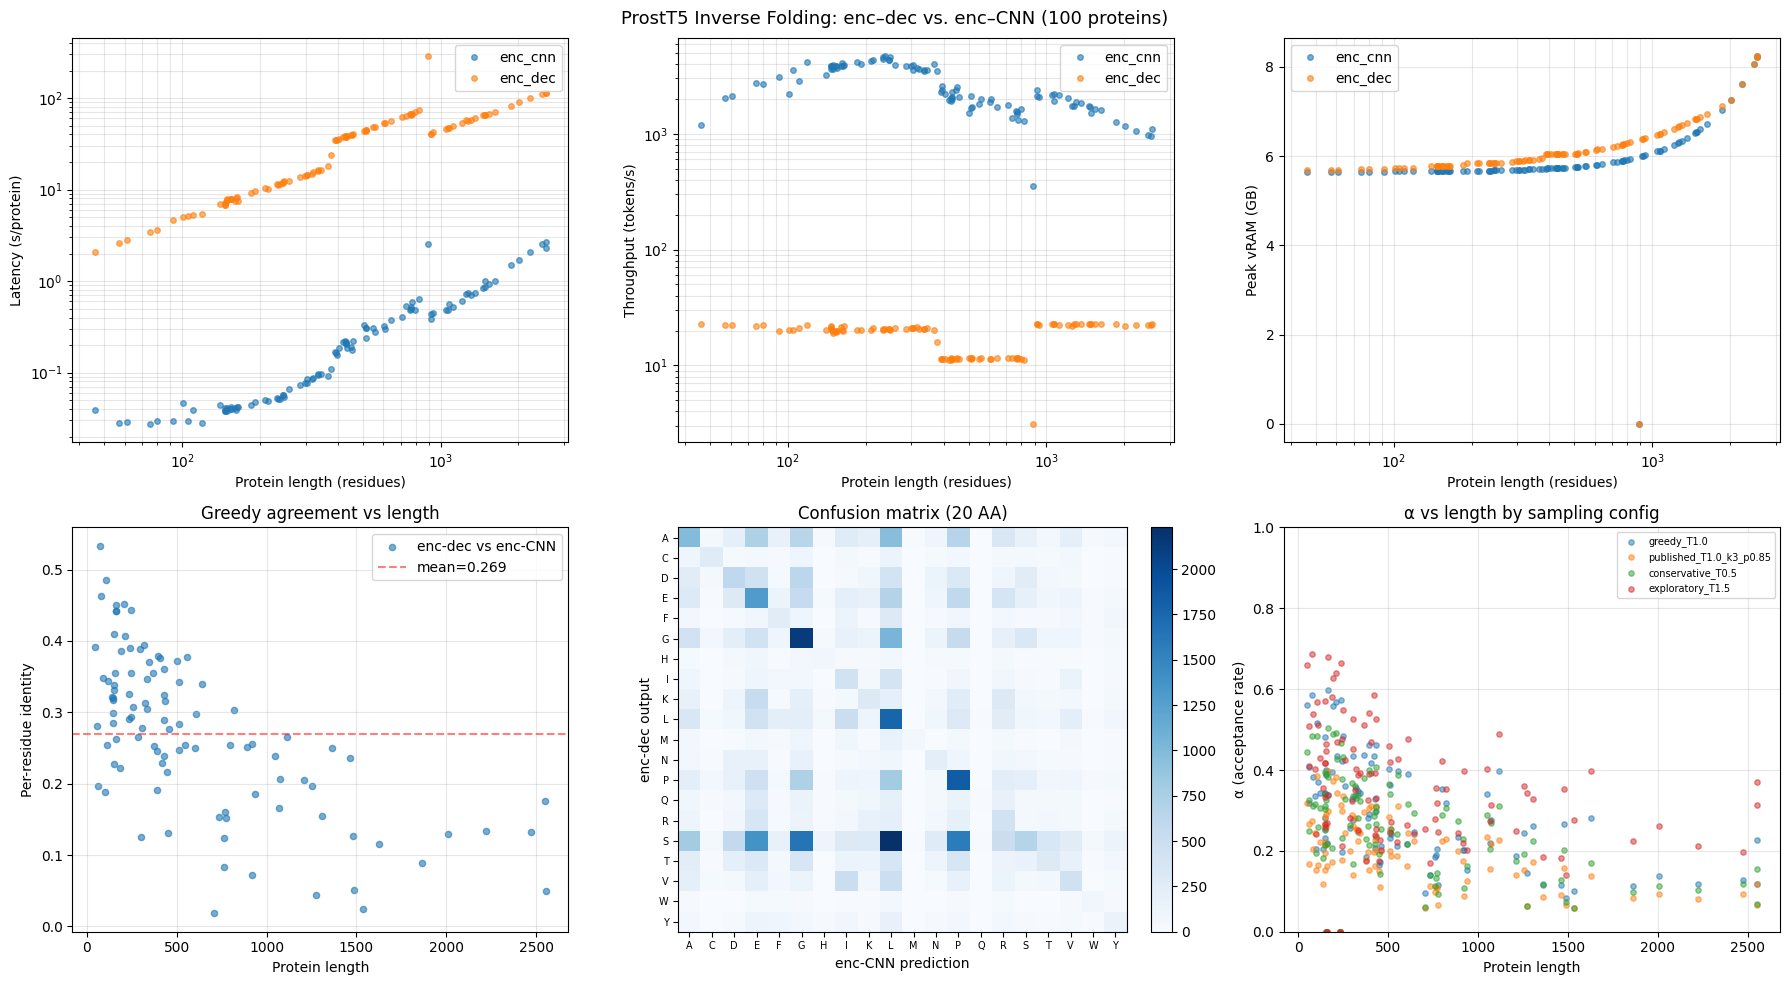

Plots saved to /kaggle/working/benchmark_results/benchmark_plots.png


In [30]:
#@title Plots: latency / throughput / vRAM / agreement / alpha. { display-mode: "form" }
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Performance plots
for ax, metric, ylabel, log in [
    (axes[0, 0], "latency_s_median", "Latency (s/protein)", True),
    (axes[0, 1], "tokens_per_s", "Throughput (tokens/s)", True),
    (axes[0, 2], "peak_vram_gb", "Peak vRAM (GB)", False),
]:
    for pipeline, sub in summary.groupby("pipeline"):
        sub = sub.sort_values("length")
        ax.plot(sub["length"], sub[metric], "o", label=pipeline, alpha=0.6, markersize=4)
    ax.set_xlabel("Protein length (residues)")
    ax.set_ylabel(ylabel)
    if log: ax.set_yscale("log")
    ax.set_xscale("log")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()

# Row 2, Left: Agreement vs length
ax = axes[1, 0]
ax.scatter(agree_df["length"], agree_df["encdec_vs_enccnn_identity"],
           alpha=0.6, s=20, label="enc-dec vs enc-CNN")
ax.axhline(agree_df["encdec_vs_enccnn_identity"].mean(), color="red",
           linestyle="--", alpha=0.5, label=f"mean={agree_df['encdec_vs_enccnn_identity'].mean():.3f}")
ax.set_xlabel("Protein length")
ax.set_ylabel("Per-residue identity")
ax.set_title("Greedy agreement vs length")
ax.legend()
ax.grid(True, alpha=0.3)

# Row 2, Middle: Confusion matrix heatmap
ax = axes[1, 1]
im = ax.imshow(global_cm, cmap="Blues", aspect="auto")
ax.set_xticks(range(20))
ax.set_yticks(range(20))
ax.set_xticklabels(list(AA_LETTERS), fontsize=7)
ax.set_yticklabels(list(AA_LETTERS), fontsize=7)
ax.set_xlabel("enc-CNN prediction")
ax.set_ylabel("enc-dec output")
ax.set_title("Confusion matrix (20 AA)")
plt.colorbar(im, ax=ax, fraction=0.046)

# Row 2, Right: Alpha by config
ax = axes[1, 2]
if len(alpha_df) > 0:
    for config in SAMPLING_CONFIGS.keys():
        subset = alpha_df[alpha_df["config"] == config].sort_values("length")
        if len(subset) > 0:
            ax.scatter(subset["length"], subset["alpha_mean"],
                      alpha=0.5, s=15, label=config)
    ax.set_xlabel("Protein length")
    ax.set_ylabel("α (acceptance rate)")
    ax.set_title("α vs length by sampling config")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

fig.suptitle("ProstT5 Inverse Folding: enc–dec vs. enc–CNN (100 proteins)", fontsize=13)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "benchmark_plots.png", dpi=150)
plt.show()
print(f"Plots saved to {RESULTS_DIR / 'benchmark_plots.png'}")

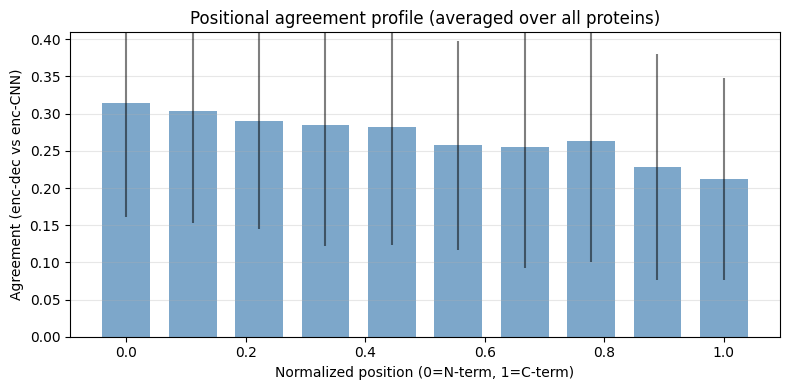

In [31]:
#@title Positional agreement analysis. { display-mode: "form" }

# Average positional agreement across all proteins
all_pos = [row["positional_agreement"] for _, row in agree_df.iterrows()
           if isinstance(row.get("positional_agreement"), list)]

if all_pos:
    n_bins = len(all_pos[0])
    mean_pos = [np.mean([p[i] for p in all_pos]) for i in range(n_bins)]
    std_pos = [np.std([p[i] for p in all_pos]) for i in range(n_bins)]

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.linspace(0, 1, n_bins)
    ax.bar(x, mean_pos, width=0.08, alpha=0.7, color="steelblue")
    ax.errorbar(x, mean_pos, yerr=std_pos, fmt="none", color="black", alpha=0.5)
    ax.set_xlabel("Normalized position (0=N-term, 1=C-term)")
    ax.set_ylabel("Agreement (enc-dec vs enc-CNN)")
    ax.set_title("Positional agreement profile (averaged over all proteins)")
    ax.set_ylim(0, max(mean_pos) * 1.3 if mean_pos else 1)
    ax.grid(True, alpha=0.3, axis="y")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / "positional_agreement.png", dpi=150)
    plt.show()
else:
    print("No positional data available.")